In [1]:
import os
import sys
import traci
import sumolib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

## Linea Base: Control Semaforico de Tiempos Fijos

Para establecer la linea base de evaluacion empirica, se implemento la simulacion del
sistema de control semaforico de tiempos fijos mediante un entorno en Python que
interactua con el simulador microscopico SUMO a traves de la API TraCI.

Referencia:
- A Deep Adaptive Traffic Signal Controller With Long-Term Planning Horizon (2024)
  https://doi.org/10.3390/app14041531
- Deep Reinforcement Learning based approach for Traffic Signal Control (2022)
  https://doi.org/10.1016/j.trpro.2022.02.035
- Enhancing traffic signal control with composite deep intelligence (2023)
  https://doi.org/10.1016/j.eswa.2023.123020

In [2]:
# Path SUMO para la simulacion
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)

# Usar libsumo
os.environ['LIBSUMO_AS_TRACI'] = '1'

# Ejecutar simulacion
# sumo = no UI
# sumo-gui = UI
sumo_binary = sumolib.checkBinary('sumo') 
# Rutas de archivos de simulación
archivo_red = os.path.join("..", "Simple_Intersection.net.xml")
archivo_rutas = os.path.join("..", "Distribuciones", "loja_intersection_weibull.rou.xml")
ruta_tripinfo = "resultados/tripinfo.xml"

sumo_cmd = [
    sumo_binary, 
    "-n", archivo_red,
    "-r", archivo_rutas,
    "--no-step-log", "true",
    "--tripinfo-output", ruta_tripinfo,
    "-W"
]

## Metricas Recolectadas

Las variables recolectadas durante la simulacion son:

**Tasa de llegada (Arrival Rate):** Ventana movil de 30 segundos (6 pasos de 5s).
Registra la variabilidad estocastica de la demanda y provee umbrales para la
discretizacion del espacio de estados del agente Q-Learning.

**Longitud de cola (Queue Length):** Vehiculos con velocidad < 0.1 m/s.
Mide la congestion fisica de la interseccion en cada instante.
Ref: Adaptive traffic signal control using deep RL (2024)
     Co-Optimization and Interpretability of Signal Control (2025)
     https://doi.org/10.3390/su17167521

**Tiempo de espera promedio (Average Waiting Time):** Promedio del tiempo de detencion
acumulado de todos los vehiculos activos. Variable principal de optimizacion.
Ref: A Novel Deep Reinforcement Learning Approach (2023)
     Reinforcement learning for traffic signal control (2025)
     https://doi.org/10.1007/s11227-025-07892-6

**Velocidad promedio (Average Speed):** Refleja la movilidad holistica del entorno.

**Tiempo perdido (Time Loss):** Retraso generado respecto a un recorrido en flujo libre.
Ref: A Novel Deep Reinforcement Learning Approach (2023)
     Deep Q-network-based traffic signal control models (2021)
     https://doi.org/10.1371/journal.pone.0256405

La recoleccion secuencial de estas variables se exporta a un archivo .csv que conforma
la linea base contra la cual se contrastara el rendimiento de Q-Learning y DQN.
Ref: Deep Q-network-based traffic signal control models (2021)
     Traffic Signal Control Optimization Based on Neural Network (2024)
     https://doi.org/10.3390/act13070251

In [3]:
datos_simulacion = []
ventana_llegadas = []  # buffer de llegadas por paso

try:
    traci.start(sumo_cmd)
    while traci.simulation.getMinExpectedNumber() > 0:
        traci.simulationStep()
        step_actual = traci.simulation.getTime()
        vehiculos_ids = traci.vehicle.getIDList()
        num_vehiculos = len(vehiculos_ids)

        # llegada = vehiculos que entraron a la red desde el paso anterior
        arrival_step = traci.simulation.getDepartedNumber()  # vehiculos insertados en este paso (5s)
        ventana_llegadas.append(arrival_step)
        if len(ventana_llegadas) > 6:  # 6 pasos x 5s = 30s
            ventana_llegadas.pop(0)
        arrival_rate = sum(ventana_llegadas)

        if num_vehiculos > 0:
            velocidades = [traci.vehicle.getSpeed(v) for v in vehiculos_ids]
            vehiculos_en_cola = sum(1 for v in velocidades if v < 0.1)
            tiempos_espera = [traci.vehicle.getWaitingTime(v) for v in vehiculos_ids]
            tiempos_perdidos = [traci.vehicle.getTimeLoss(v) for v in vehiculos_ids]

            datos_simulacion.append({
                "Paso_Tiempo": step_actual,
                "Vehiculos_Activos": num_vehiculos,
                "Cola_Actual": vehiculos_en_cola,
                "Velocidad_Min": np.min(velocidades),
                "Velocidad_Max": np.max(velocidades),
                "Velocidad_Promedio": np.mean(velocidades),
                "TiempoEspera_Promedio": np.mean(tiempos_espera),
                "TiempoPerdido_Promedio": np.mean(tiempos_perdidos),
                "Arrival_Rate": arrival_rate,  # NUEVO
            })
finally:
    traci.close()

df_metricas = pd.DataFrame(datos_simulacion)
print("Simulación finalizada. Datos recolectados:", len(df_metricas), "pasos.")

ruta_csv_seguro = "resultados/metricas.csv"
os.makedirs("resultados", exist_ok=True)
df_metricas.to_csv(ruta_csv_seguro, index=False)

 Retrying in 1 seconds
Simulación finalizada. Datos recolectados: 3539 pasos.


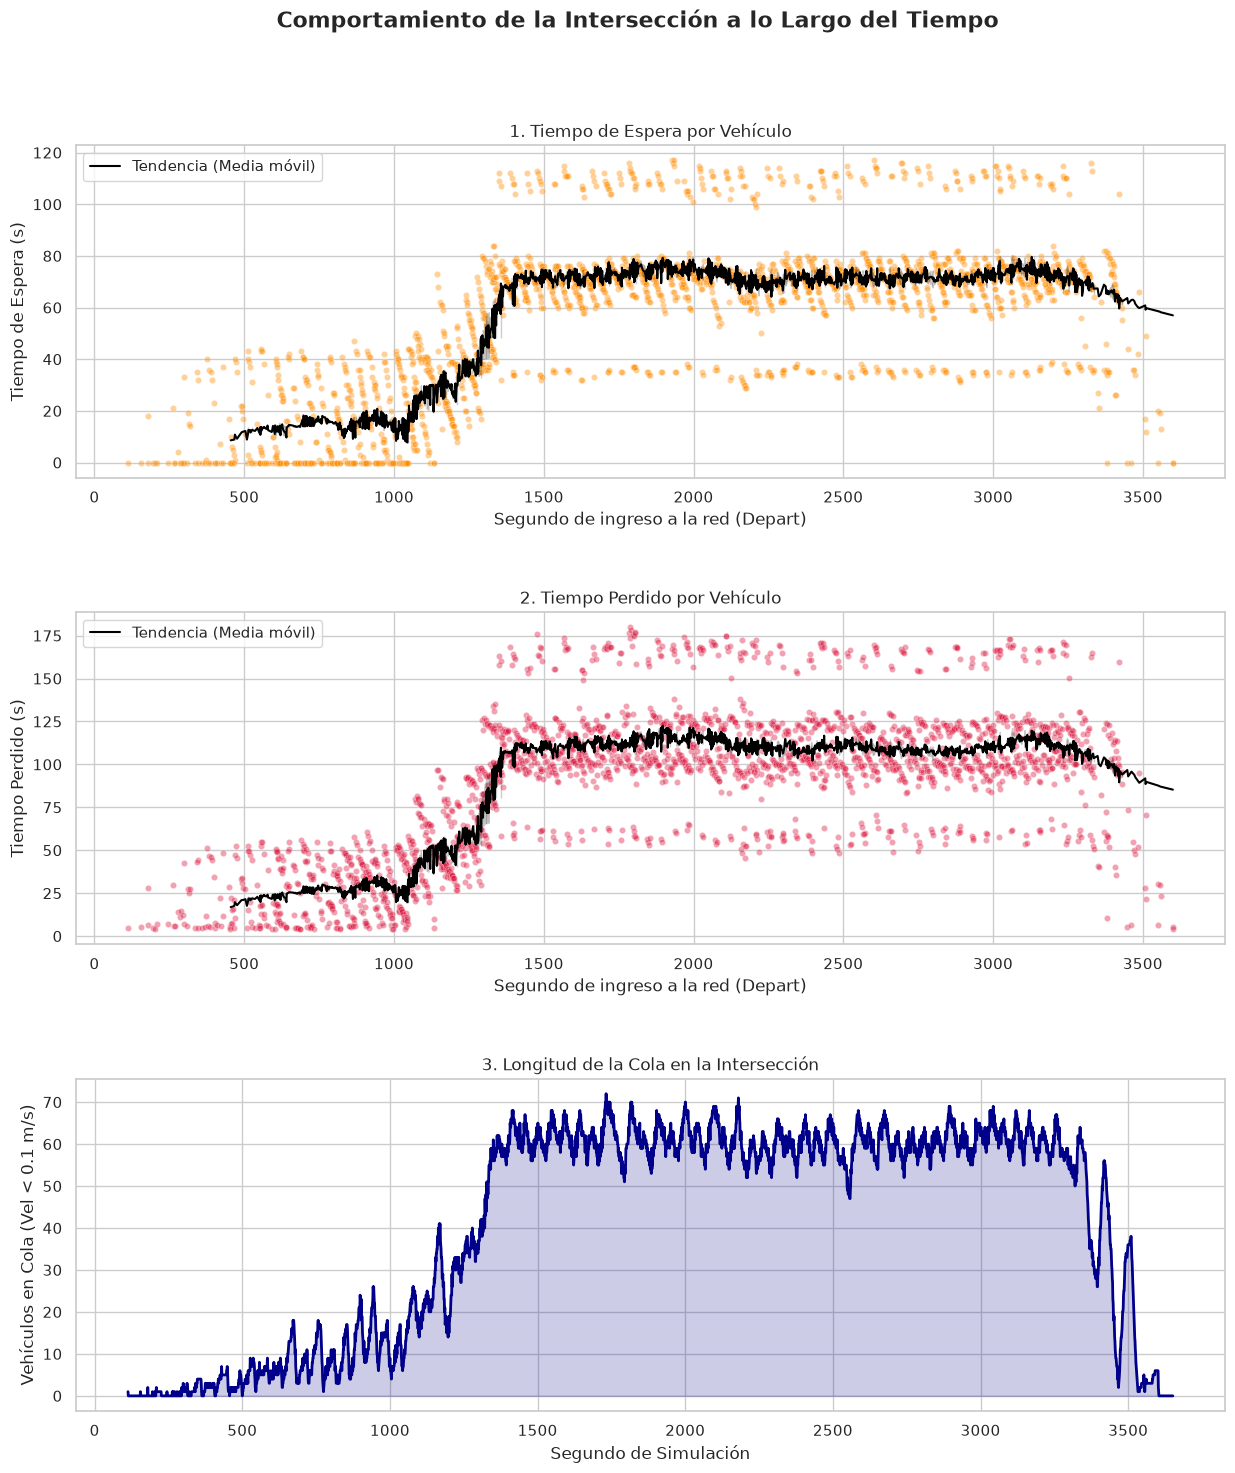

In [4]:
# Estilo
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Cargar datos de viajes
ruta_xml = "resultados/tripinfo.xml"
df_trips = pd.read_xml(ruta_xml)

# Convertir columnas a numéricas
for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

# 3. Crear el lienzo con 3 subgráficas verticales
fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0) # Espacio para que no se superpongan los textos
fig.suptitle('Comportamiento de la Intersección a lo Largo del Tiempo', fontsize=16, fontweight='bold', y=1.02)

# --- GRÁFICA 1: Tiempo de Espera de CADA vehículo ---
sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Tendencia (Media móvil)', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehículo")
axs[0].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

# --- GRÁFICA 2: Tiempo Perdido de CADA vehículo ---
sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Tendencia (Media móvil)', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehículo")
axs[1].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

# Grafica 3: Cola a lo largo del tiempo
if 'df_metricas' in locals():
    axs[2].plot(df_metricas['Paso_Tiempo'], df_metricas['Cola_Actual'], color='darkblue', linewidth=2)
    axs[2].fill_between(df_metricas['Paso_Tiempo'], df_metricas['Cola_Actual'], color='darkblue', alpha=0.2)
    axs[2].set_title("3. Longitud de la Cola en la Intersección")
    axs[2].set_xlabel("Segundo de Simulación")
    axs[2].set_ylabel("Vehículos en Cola (Vel < 0.1 m/s)")
else:
    axs[2].text(0.5, 0.5, 'Requiere el DataFrame df_metricas generado por TraCI', horizontalalignment='center', fontsize=12)
    axs[2].set_title("3. Longitud de la Cola en la Intersección")

plt.show()

In [5]:
# Asegurar tipo numérico
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

# Calcular velocidad efectiva por vehículo (km/h)
df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

# Métricas por paso de tiempo

# Cálculo de variables
promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()

promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()

velocidad_media_global = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)

cola_promedio = df_metricas['Cola_Actual'].mean()
cola_maxima = df_metricas['Cola_Actual'].max()

ventana_llegadas.append(arrival_step)
if len(ventana_llegadas) > 6:  # 6 pasos x 5s = 30s de ventana
    ventana_llegadas.pop(0)
arrival_rate = sum(ventana_llegadas)

# Impresión de resultados
print("="*50)
print("  REPORTE DE MÉTRICAS: LÍNEA BASE (TIEMPOS FIJOS)")
print("="*50)
print("\n--- Rendimiento General ---")
print(f"Total de vehículos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media_global:.2f} km/h")

print("\n--- Demora Vehicular (Tripinfo) ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MÁXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MÁXIMO         : {maximo_perdido:.2f} s")

print("\n--- Ocupación de la Intersección (TraCI) ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehículos")
print(f"Longitud de cola MÁXIMA       : {cola_maxima} vehículos")
print("="*50)

# Vista de los primeros valores del dataset
display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  REPORTE DE MÉTRICAS: LÍNEA BASE (TIEMPOS FIJOS)

--- Rendimiento General ---
Total de vehículos procesados : 2418
Velocidad promedio del sistema: 18.17 km/h

--- Demora Vehicular (Tripinfo) ---
Tiempo de espera promedio     : 57.63 s
Tiempo de espera MÁXIMO       : 117.00 s
Tiempo perdido promedio       : 89.80 s
Tiempo perdido MÁXIMO         : 180.00 s

--- Ocupación de la Intersección (TraCI) ---
Longitud de cola promedio     : 40.06 vehículos
Longitud de cola MÁXIMA       : 72 vehículos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,49.0,0.0,4.92
1,veh_1,154.0,52.0,0.0,5.01
2,veh_2,179.0,51.0,0.0,6.48
3,veh_4,195.0,49.0,0.0,4.79
4,veh_3,179.0,72.0,18.0,27.77


In [6]:
import pandas as pd

df_check = pd.read_csv("resultados/metricas.csv")
print(df_check.columns.tolist())
print(df_check["Arrival_Rate"].describe())
print(df_check["Arrival_Rate"].value_counts().head(10))

['Paso_Tiempo', 'Vehiculos_Activos', 'Cola_Actual', 'Velocidad_Min', 'Velocidad_Max', 'Velocidad_Promedio', 'TiempoEspera_Promedio', 'TiempoPerdido_Promedio', 'Arrival_Rate']
count    3539.000000
mean        4.099463
std         2.269255
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        11.000000
Name: Arrival_Rate, dtype: float64
Arrival_Rate
4    955
5    575
6    385
0    352
7    285
3    282
1    247
2    222
8    164
9     63
Name: count, dtype: int64


## bin_edges - Calibracion de Bins

Funcion para calcular limites de bins usando percentiles.

Referencia:
- Originalmente el paper usa rangos genericos para discretizar el estado.
- Aqui se calibran con datos reales del baseline de tiempos fijos
  para mejor representacion del trafico real.

Dimensiones:
- nvehiculos (6 bins): vehiculos activos en la interseccion
- waiting (6 bins): tiempo de espera promedio por vehiculo
- queue (4 bins): longitud de cola (velocidad < 0.1 m/s)
- arrival (3 bins): tasa de llegada (ventana de 30s)

In [7]:
import numpy as np
import pandas as pd
import os

df_metricas = pd.read_csv("resultados/metricas.csv")

def bin_edges(datos, n_bins):
    percentiles = np.linspace(0, 100, n_bins + 1)[1:-1]
    return np.percentile(datos, percentiles)

EDGES_NVEHICULOS = bin_edges(df_metricas["Vehiculos_Activos"], 6)
EDGES_WAITING    = bin_edges(df_metricas["TiempoEspera_Promedio"], 6)
EDGES_QUEUE      = bin_edges(df_metricas["Cola_Actual"], 4)
EDGES_ARRIVAL    = bin_edges(df_metricas["Arrival_Rate"], 3)

print("=" * 56)
print("  EDGES CALIBRADOS CON TRAFICO REAL (tiempo fijo)")
print("=" * 56)
print(f"nvehiculos (6 bins): {np.round(EDGES_NVEHICULOS, 1)}")
print(f"waiting    (6 bins): {np.round(EDGES_WAITING, 1)}")
print(f"queue      (4 bins): {np.round(EDGES_QUEUE, 1)}")
print(f"arrival    (3 bins): {np.round(EDGES_ARRIVAL, 1)}")
print("=" * 56)

  EDGES CALIBRADOS CON TRAFICO REAL (tiempo fijo)
nvehiculos (6 bins): [ 30.   74.3 128.  131.  133. ]
waiting    (6 bins): [1.6 5.7 7.9 8.3 9. ]
queue      (4 bins): [10. 56. 61.]
arrival    (3 bins): [4. 5.]


## Guardado de Bin Edges

Los edges calibrados se guardan en `resultados/bin_edges_calibrados.npz`
para ser usados por Q-Learning en la discretizacion de estados.

In [8]:
os.makedirs("resultados", exist_ok=True)
np.savez(
    "resultados/bin_edges_calibrados.npz",
    nvehiculos=EDGES_NVEHICULOS,
    waiting=EDGES_WAITING,
    queue=EDGES_QUEUE,
    arrival=EDGES_ARRIVAL,
)
print("Edges guardados en resultados/bin_edges_calibrados.npz")

Edges guardados en resultados/bin_edges_calibrados.npz
